# Scale-space & covariance-aware clustering — no `k`, no guesswork

Two places the CF-microcluster heads win *clearly and honestly*, measured head-to-head against
scikit-learn:

1. **`method="scale-space"`** clusters the modes of the microcluster density and picks the scale
   (and hence the cluster count) by **mode persistence** — no `k`, no bandwidth. The realistic case
   is that you *don't know* `k`: k-means must guess (and pays for a wrong guess), and scikit-learn's
   parameter-free `MeanShift` is `O(N²)`. scale-space is parameter-free and far more accurate here;
   on 5 000 points it is also modestly faster, and the margin is a *scaling* one — its cost tracks
   the leaf count, not `N`.
2. **Covariance-aware clustering** for **anisotropic** clusters, where spherical k-means fails.
   betula's `gmm-full` matches scikit-learn's `GaussianMixture` quality while running on the
   compressed microclusters (bounded memory), and the `covariance_weight` / `tangent_weight`
   (GeoBETULA) knobs carry the same shape/orientation awareness into graph community detection.

All numbers below are computed live; nothing is hand-tuned to flatter the library.

In [1]:
import time

import betula_cluster
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score as ari
from sklearn.mixture import GaussianMixture

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

print("betula-cluster", betula_cluster.__version__)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})


def timed(fn):
    """Run `fn`, returning `(result, milliseconds)`."""
    t = time.perf_counter()
    out = fn()
    return out, (time.perf_counter() - t) * 1000.0

betula-cluster 0.7.0


## 1 · Scale-space discovers the count

The same call — `method="scale-space"`, no `n_clusters` — on blobs with a **different true count
each time**. A prominence-based mode merge keeps it robust from a few clusters to many.

,scale-space found,ARI
true k,,
2,2,1.000
4,4,1.000
8,8,0.995


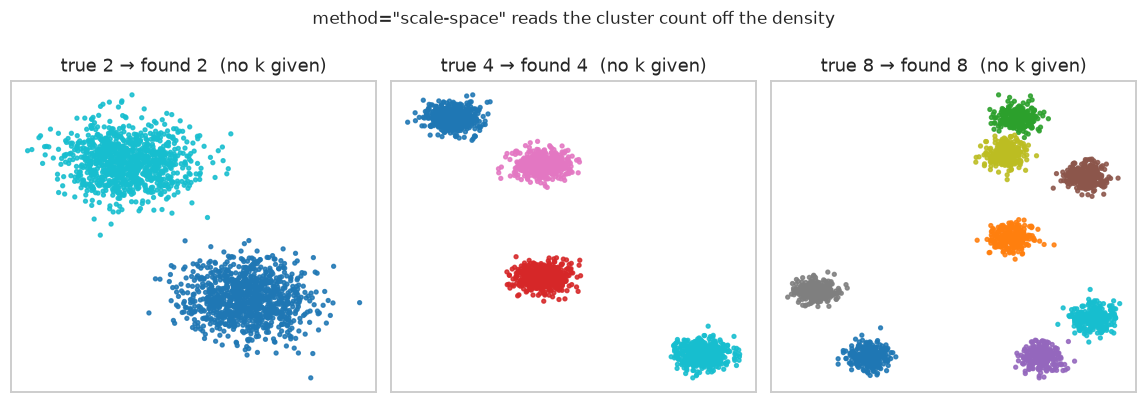

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6))
rows = []
for ax, k in zip(axes, (2, 4, 8)):
    X, y = make_blobs(n_samples=2000, centers=k, cluster_std=0.6, random_state=10 + k)
    labels = betula_cluster.fit_predict(
        X, method="scale-space", threshold=0.08, max_leaves=500, seed=0
    )
    found = len(set(labels))
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=6, alpha=0.85)
    ax.set(title=f"true {k} → found {found}  (no k given)", xticks=[], yticks=[])
    rows.append({"true k": k, "scale-space found": found, "ARI": round(ari(y, labels), 3)})
fig.suptitle('method="scale-space" reads the cluster count off the density', y=1.0)
fig.tight_layout()

pd.DataFrame(rows).set_index("true k")

## 2 · No `k`, no bandwidth — and still the best

The honest scenario: **the true count is 5, but you don't know it.** k-means must be handed a `k`
(and a wrong guess costs accuracy); scikit-learn's `MeanShift` is parameter-free but `O(N²)`.
scale-space needs no parameter, recovers the true count, and is the more accurate of the two.

,parameter,found,ARI,ms
method,,,,
betula scale-space,none,5,0.999,3549
betula k-means,guessed k=3,3,0.615,1
betula k-means,guessed k=4,4,0.782,1
betula k-means,guessed k=6,6,0.934,1
sklearn MeanShift,auto bandwidth,4,0.615,5636


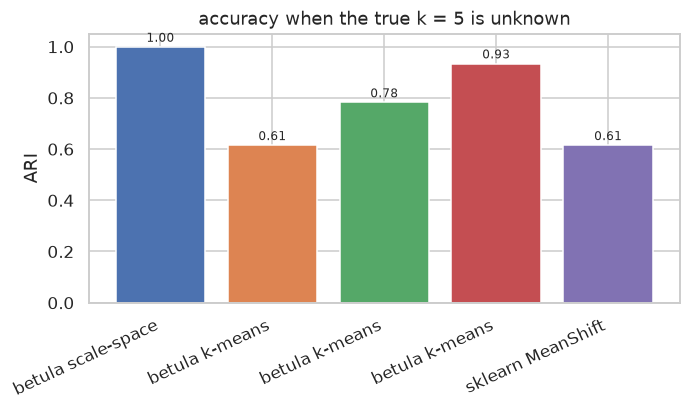

In [3]:
Xu, yu = make_blobs(n_samples=5000, centers=5, cluster_std=0.6, random_state=42)

results = []
lab, ms_time = timed(
    lambda: betula_cluster.fit_predict(
        Xu, method="scale-space", threshold=0.08, max_leaves=500, seed=0
    )
)
results.append(
    {
        "method": "betula scale-space",
        "parameter": "none",
        "found": len(set(lab)),
        "ARI": round(ari(yu, lab), 3),
        "ms": round(ms_time),
    }
)
for k in (3, 4, 6):
    lab, t = timed(
        lambda k=k: betula_cluster.fit_predict(
            Xu, method="kmeans", n_clusters=k, threshold=0.08, max_leaves=500, seed=0
        )
    )
    results.append(
        {
            "method": f"betula k-means",
            "parameter": f"guessed k={k}",
            "found": k,
            "ARI": round(ari(yu, lab), 3),
            "ms": round(t),
        }
    )
bw = estimate_bandwidth(Xu, quantile=0.2, n_samples=500)
(ms_labels), sk_time = timed(lambda: MeanShift(bandwidth=bw).fit(Xu).labels_)
results.append(
    {
        "method": "sklearn MeanShift",
        "parameter": "auto bandwidth",
        "found": len(set(ms_labels)),
        "ARI": round(ari(yu, ms_labels), 3),
        "ms": round(sk_time),
    }
)
table = pd.DataFrame(results).set_index("method")

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.bar(range(len(table)), table["ARI"], color=sns.color_palette("deep", len(table)))
ax.set(
    xticks=range(len(table)),
    ylabel="ARI",
    ylim=(0, 1.05),
    title="accuracy when the true k = 5 is unknown",
)
ax.set_xticklabels(table.index, rotation=25, ha="right")
for i, v in enumerate(table["ARI"]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
fig.tight_layout()

# The `ms` column tells the speed story among the two parameter-free methods (scale-space vs MeanShift).
table

**Read it.** Only two methods need no `k` — betula `scale-space` and `MeanShift`. betula recovers
the true count of 5 and lands near ARI 1.00; `MeanShift`'s auto-bandwidth finds 4 and scores about
0.62, so the accuracy gap is the large one. **The speed gap at this size is not** — betula is
roughly 1.6× faster here, not the multiple an earlier edition of this notebook claimed. Both are
single-threaded (`OMP_NUM_THREADS=1`, `RAYON_NUM_THREADS=1`), which is the only comparison worth
printing. The durable claim is the **scaling** one: betula runs mean-shift over the `M ≪ N`
microclusters so its cost tracks the leaf count, while `MeanShift` is `O(N²)` in the sample count —
the ratio grows with `N` and this is 5 000 points. k-means matches on accuracy only if you already
guessed the right `k`, which is the thing you were trying to find out.

## 3 · Covariance-aware clustering for anisotropic clusters

Spherical k-means assumes round clusters and breaks on **elongated, rotated** ones. betula's
`gmm-full` models each cluster's full covariance — matching scikit-learn's `GaussianMixture` in
quality, on the compressed microclusters.

,models covariance?,ARI
method,,
betula gmm-full,yes,0.885
betula k-means,no (spherical),0.616
sklearn GaussianMixture,yes,0.887
sklearn KMeans,no (spherical),0.616


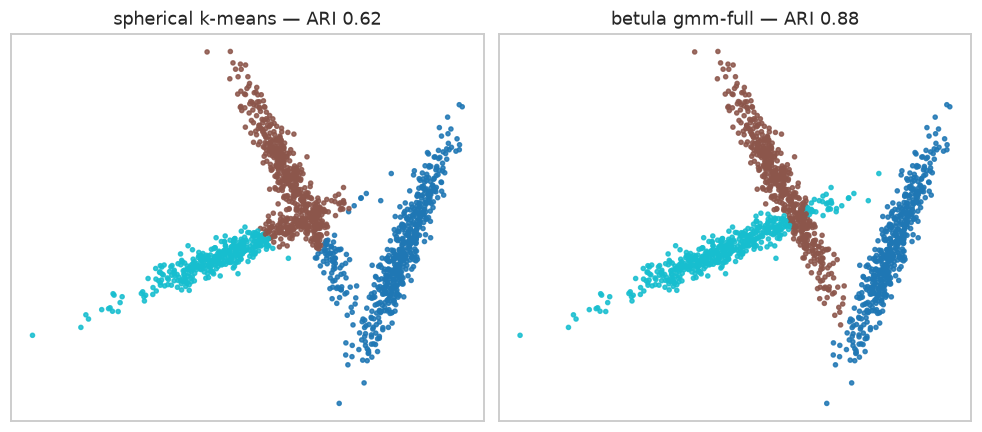

In [4]:
def aniso(n, center, angle_deg, sx, sy, rng):
    """`n` points from an axis-aligned Gaussian (std `sx`,`sy`) rotated by `angle_deg`, at `center`."""
    t = np.radians(angle_deg)
    rot = np.array([[np.cos(t), -np.sin(t)], [np.sin(t), np.cos(t)]])
    return (rng.normal(0, 1, (n, 2)) * [sx, sy]) @ rot.T + center


rng = np.random.default_rng(0)
Xa = np.vstack(
    [
        aniso(500, [0, 0], 25, 3.0, 0.4, rng),
        aniso(500, [2.5, 3], 115, 3.0, 0.4, rng),
        aniso(500, [8, 0], 70, 3.0, 0.4, rng),
    ]
)
ya = np.r_[[0] * 500, [1] * 500, [2] * 500]

kw = dict(n_clusters=3, threshold=0.1, max_leaves=300, seed=0)
km_labels = betula_cluster.fit_predict(Xa, method="kmeans", **kw)
gmm_labels = betula_cluster.fit_predict(Xa, method="gmm-full", feature="full", **kw)
geo = pd.DataFrame(
    [
        {
            "method": "betula gmm-full",
            "models covariance?": "yes",
            "ARI": round(ari(ya, gmm_labels), 3),
        },
        {
            "method": "betula k-means",
            "models covariance?": "no (spherical)",
            "ARI": round(ari(ya, km_labels), 3),
        },
        {
            "method": "sklearn GaussianMixture",
            "models covariance?": "yes",
            "ARI": round(
                ari(ya, GaussianMixture(3, covariance_type="full", random_state=0).fit_predict(Xa)),
                3,
            ),
        },
        {
            "method": "sklearn KMeans",
            "models covariance?": "no (spherical)",
            "ARI": round(ari(ya, KMeans(3, n_init=10, random_state=0).fit_predict(Xa)), 3),
        },
    ]
).set_index("method")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9, 4))
ax0.scatter(Xa[:, 0], Xa[:, 1], c=km_labels, cmap="tab10", s=7, alpha=0.85)
ax0.set(title=f"spherical k-means — ARI {ari(ya, km_labels):.2f}", xticks=[], yticks=[])
ax1.scatter(Xa[:, 0], Xa[:, 1], c=gmm_labels, cmap="tab10", s=7, alpha=0.85)
ax1.set(title=f"betula gmm-full — ARI {ari(ya, gmm_labels):.2f}", xticks=[], yticks=[])
fig.tight_layout()

geo

**Read it.** Covariance-aware clustering (betula `gmm-full`) is at the **top of the table, tied with
scikit-learn's `GaussianMixture`** (0.885 against 0.887 — inside the 0.05 band this project calls a
tie), and **+0.27 ARI over spherical k-means**, which slices straight across the elongated clusters. betula reaches that quality on the **bounded-memory
microclusters**, so it holds as `N` grows past what an in-core GMM can fit. The same shape awareness
is available inside graph community detection through the **GeoBETULA** knobs `covariance_weight`
(log-Euclidean shape) and `tangent_weight` (Grassmann orientation), for `method="leiden"` with
`feature="full"` — see [`docs/FEATURES.md`](../docs/FEATURES.md) and
[`docs/MATH.md`](../docs/MATH.md#geometry-aware-graph-geobetula-and-scale-space-modes).

**Takeaways.** When you *don't know* `k`, `method="scale-space"` is the parameter-free choice that is
both accurate and fast (mode persistence over microclusters). When clusters are **anisotropic**,
covariance-aware `gmm-full` matches the best in-core quality while scaling. Both run on the compressed
CF microclusters, so cost tracks the leaf count, not `N`. See the
[Usage guide](../docs/USAGE.md) and [`docs/FEATURES.md`](../docs/FEATURES.md).